# How Should Apples be Prepared for a Fruit Salad? Part 2

This is a continuation of the work from Part I. This notebook focuses on studying the effect of inhibitors on the browning reaction.

**(Revised March 19 2025 KH, converted to Python 2026)**

## Attribution:

This code was developed by Dora Geng and Dr. Kathryn Haas (2024, CC-BY-NC-SA) with assistance from ChatGPT. Converted to Python in 2026.

Parts I and II of this experiment are adapted from:
- Cole, Renée S., Marc Muniz, Erica Harvey, Robert Sweeney, and **Sally Hunnicutt**. "How Should Apples Be Prepared for a Fruit Salad? A Guided Inquiry Physical Chemistry Experiment." *Journal of Chemical Education* 97, no. 12 (December 8, 2020): 4475–81. https://doi.org/10.1021/acs.jchemed.0c00517.
- Fun Fact: Sally Hunnicutt is a Duke Alum! Chemistry Major '83

## Import Required Libraries

## About This Notebook

**Note on Programming Style**: In Part 1, we wrote out each command separately for clarity. In this Part 2 notebook, we'll introduce some advanced Python features that make our code more efficient:

- Lists: We'll organize our run numbers into lists (e.g., `[14, 15, 16, 18]`) so we can work with groups of data
- For loops: We'll use loops to repeat operations instead of typing the same code many times
- Dictionaries: We'll store our data in dictionaries (e.g., `runs_data[19]`) for easy access by run number



In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
import warnings
import os
warnings.filterwarnings('ignore')

# Part II: Data Import

Set up the import options for your Part II data files. You will need to set:

1. Data directory: Where your data files are stored (same as Part 1)
2. Base filename: The common part of all your file names (everything before `_Run`)
3. Number of rows to skip: Specify which row to start reading data from

It is important that you adjust the row numbers to include only the useful data. Usually, a number between 20-25 should work for the first row, but check your plot after import and adjust as necessary.

## Set your data directory and base filename

In [13]:
# Set your data directory (leave empty "" if files are in the same folder as this notebook)
data_directory = "20250319_RedDelicious"  # For example: "data" or "my_data_folder"

# Set your base filename here (everything before "_Run")
# For example: "20250228_Gala" if your files are "20250228_Gala_Run14.txt"
base_filename = "20250319_RedDelicious"

# Set the row to start reading data
skiprows = 21  # This skips the first 21 rows (0-indexed), starts reading at row 22

## Import Part II data (Runs 14-38)

In the cells below, we'll:
1. Define which runs to import (organized by experimental section)
2. Use a for loop to import all the data files automatically
3. Extract the absorbance data into a dictionary for easy access



### Step 1: Define which runs to import

In Part 2, we have different groups of runs for different experiments. We'll create lists to organize them:

- Part IIA: Runs 14-18 (some datasets may be missing runs)  
- Part IIB, Inhibitor Conc 1: Runs 19-25
- Part IIB, Inhibitor Conc 2: Runs 27-32  
- Part IIB, Inhibitor Conc 3: Runs 33-38


In [14]:
# Define sublists for each experimental section
# Edit these lists if you're missing any data files
# run 17 is missing from this dataset
runs_IIA = [14, 15, 16, 18]  
runs_IIB_1 = [19, 20, 21, 22, 23, 24, 25]  # Inhibitor concentration 1
runs_IIB_2 = [27, 28, 29, 30, 31, 32]  # Inhibitor concentration 2
runs_IIB_3 = [33, 34, 35, 36, 37, 38]  # Inhibitor concentration 3

# Combine all the lists to make a complete list of all runs to import
# Run 26 is included separately as it's a control run
all_runs = runs_IIA + runs_IIB_1 + [26] + runs_IIB_2 + runs_IIB_3

print("Runs to import:", all_runs)
print(f"Total number of runs: {len(all_runs)}")

Runs to import: [14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]
Total number of runs: 24


### Step 2: Import data using a loop

Instead of typing out the same import code 25 times, we'll use a for loop to import all the data files automatically. The loop will:
- Go through each run number in our all_runs list
- Build the filename for that run
- Import the data and store it in a dictionary

We'll store all the data in a dictionary (runs_data) where the key is the run number and the value is the dataframe. This makes it easy to access any run's data later.

In [15]:
# Create an empty dictionary to store all the run data
# Dictionary keys will be run numbers, values will be dataframes
runs_data = {}

# Loop through each run number and import the data
for run_num in all_runs:
    # Build the filename for this run
    filename = os.path.join(data_directory, base_filename + f"_Run{run_num}.txt")
    
    # Import the data and store it in the dictionary
    runs_data[run_num] = pd.read_csv(filename, 
                                     sep="\t", 
                                     skiprows=skiprows,
                                     nrows=35,
                                     names=["Time", "Transmittance", "Absorbance"])
    
    print(f"Imported Run{run_num}")



Imported Run14
Imported Run15
Imported Run16
Imported Run18
Imported Run19
Imported Run20
Imported Run21
Imported Run22
Imported Run23
Imported Run24
Imported Run25
Imported Run26
Imported Run27
Imported Run28
Imported Run29
Imported Run30
Imported Run31
Imported Run32
Imported Run33
Imported Run34
Imported Run35
Imported Run36
Imported Run37
Imported Run38


## Extract absorbance data from all runs

In [16]:
# Extract absorbance data for each run
# We'll also store the time data for each run since they might have different lengths
runs_abs = {}
runs_time = {}

# Loop through each run and extract both time and absorbance data
for run_num in all_runs:
    runs_time[run_num] = runs_data[run_num]['Time'].values
    runs_abs[run_num] = runs_data[run_num]['Absorbance'].values

print(f"Extracted time and absorbance data for {len(runs_abs)} runs")

# Show an example
print(f"\nExample from Run{all_runs[0]}:")
print(f"  Number of time points: {len(runs_time[all_runs[0]])}")
print(f"  Number of absorbance points: {len(runs_abs[all_runs[0]])}")
print(f"  First 5 absorbance values: {runs_abs[all_runs[0]][:5]}")

Extracted time and absorbance data for 24 runs

Example from Run14:
  Number of time points: 35
  Number of absorbance points: 35
  First 5 absorbance values: [0.03979999 0.03949999 0.03909998 0.0388     0.03890001]


# Part IIA: Plot absorbance data

Plot the data to check correct import. Remove data points as necessary.

**Be sure to change the title and labels appropriately if you use this in your lab notebook!**



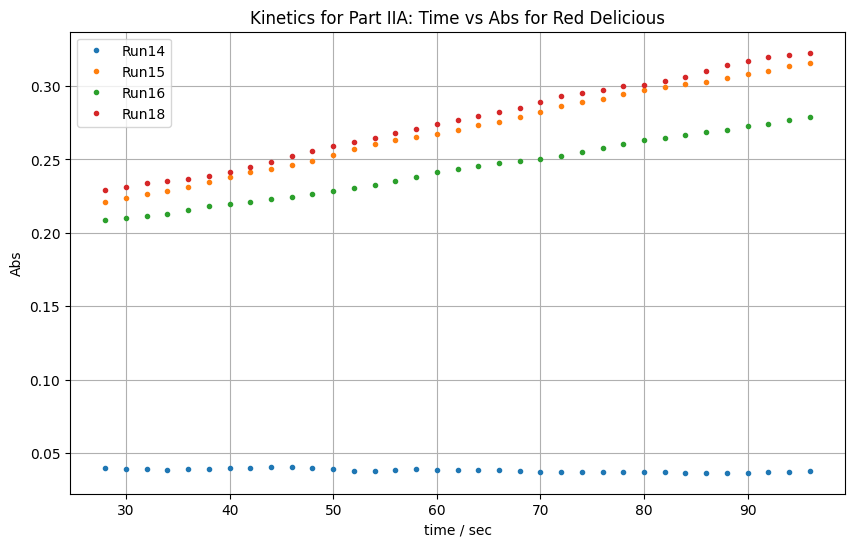

In [17]:
# Plot Part IIA data using a loop
# Each run uses its own time array to handle different data lengths
plt.figure(figsize=(10, 6))

# Loop through Part IIA runs and plot each one
for run_num in runs_IIA:
    plt.plot(runs_time[run_num], runs_abs[run_num], '.', label=f'Run{run_num}')

plt.title('Kinetics for Part IIA: Time vs Abs for Red Delicious')
plt.xlabel('time / sec')
plt.ylabel('Abs')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Part IIB: Inhibitor Studies

## Inhibitor @ Concentration 1

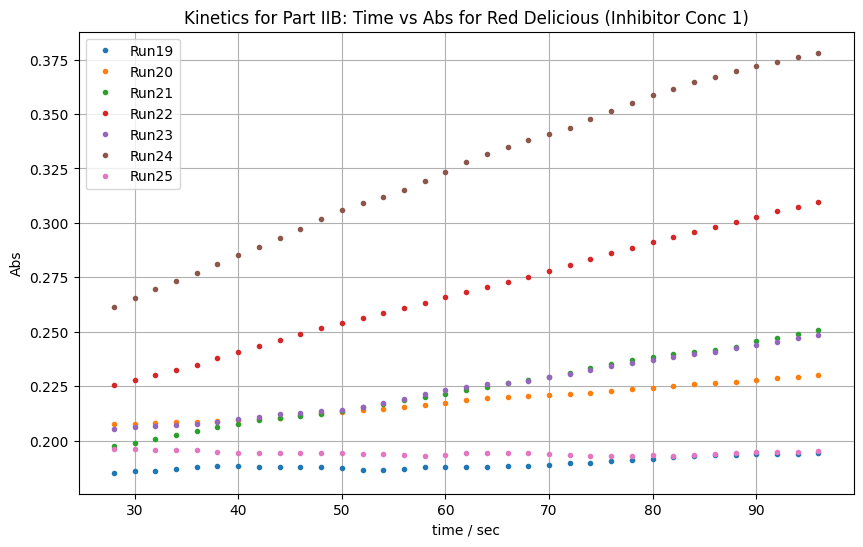

In [18]:
# Plot Inhibitor Concentration 1 data using a loop
# Each run uses its own time array to handle different data lengths
plt.figure(figsize=(10, 6))

# Loop through runs for Inhibitor Concentration 1
for run_num in runs_IIB_1:
    plt.plot(runs_time[run_num], runs_abs[run_num], '.', label=f'Run{run_num}')

plt.title('Kinetics for Part IIB: Time vs Abs for Red Delicious (Inhibitor Conc 1)')
plt.xlabel('time / sec')
plt.ylabel('Abs')
plt.legend(loc='best')
plt.grid(True)
plt.show()

## Inhibitor @ Concentration 2

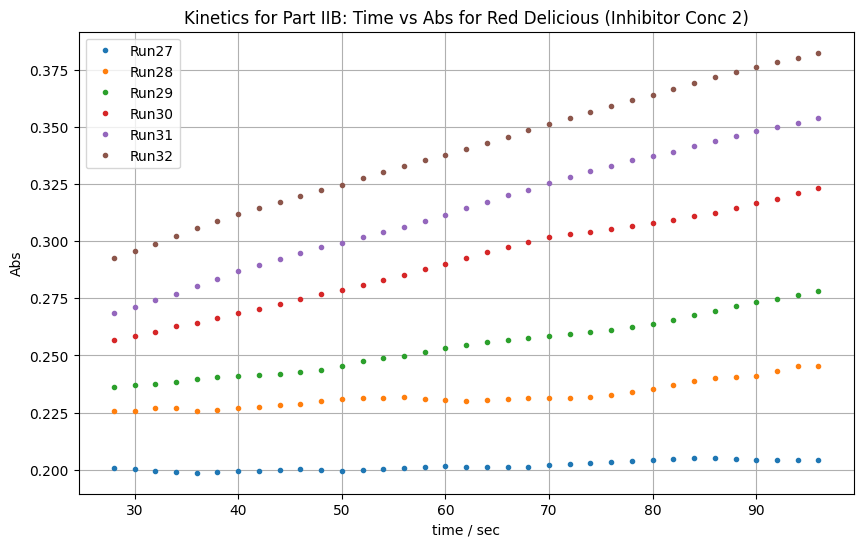

In [19]:
# Plot Inhibitor Concentration 2 data using a loop
# Each run uses its own time array to handle different data lengths
plt.figure(figsize=(10, 6))

# Loop through runs for Inhibitor Concentration 2
for run_num in runs_IIB_2:
    plt.plot(runs_time[run_num], runs_abs[run_num], '.', label=f'Run{run_num}')

plt.title('Kinetics for Part IIB: Time vs Abs for Red Delicious (Inhibitor Conc 2)')
plt.xlabel('time / sec')
plt.ylabel('Abs')
plt.legend(loc='best')
plt.grid(True)
plt.show()

## Inhibitor @ Concentration 3

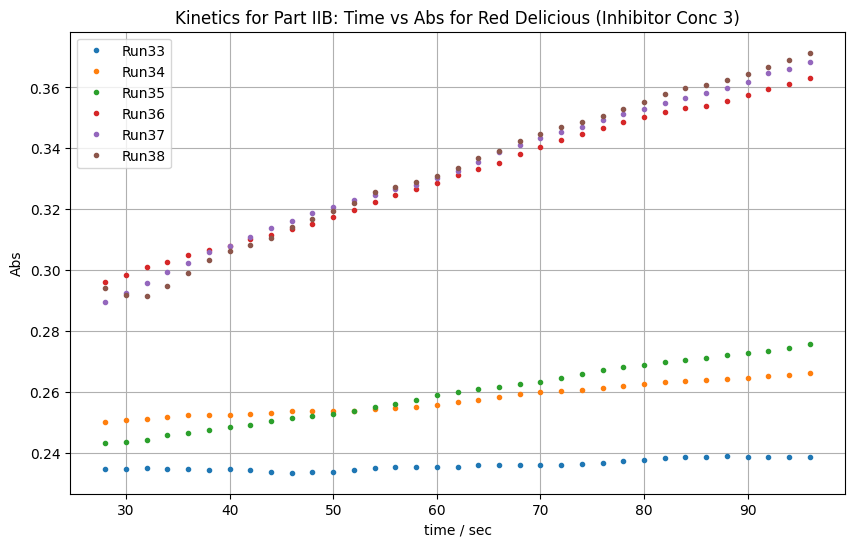

In [20]:
# Plot Inhibitor Concentration 3 data using a loop
# Each run uses its own time array to handle different data lengths
plt.figure(figsize=(10, 6))

# Loop through runs for Inhibitor Concentration 3
for run_num in runs_IIB_3:
    plt.plot(runs_time[run_num], runs_abs[run_num], '.', label=f'Run{run_num}')

plt.title('Kinetics for Part IIB: Time vs Abs for Red Delicious (Inhibitor Conc 3)')
plt.xlabel('time / sec')
plt.ylabel('Abs')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Velocity (rate)

The velocity at any time is the derivatives of the Absorbance with respect to time. We can use the np.gradient() function to calculate the derivatives.

Calculated velocities for 20 runs


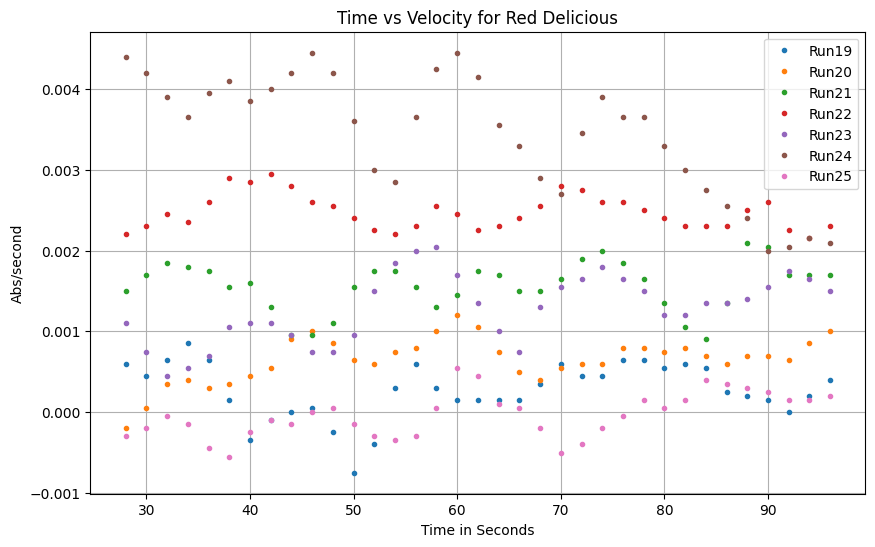

In [21]:
# Calculate velocities using a loop
# Create dictionaries to store velocity data and corresponding time arrays
runs_velocity = {}

# We only need velocities for Part IIB runs (not Part IIA)
runs_for_velocity = runs_IIB_1 + [26] + runs_IIB_2 + runs_IIB_3

# Loop through the runs and calculate the differential (velocity)
for run_num in runs_for_velocity:
    runs_velocity[run_num] = np.gradient(runs_abs[run_num])


print(f"Calculated velocities for {len(runs_velocity)} runs")

# Plot the velocity data for inhibitor concentration 1
plt.figure(figsize=(10, 6))

for run_num in runs_IIB_1:
    plt.plot(runs_time[run_num], runs_velocity[run_num], '.', label=f'Run{run_num}')

plt.title('Time vs Velocity for Red Delicious')
plt.xlabel('Time in Seconds')
plt.ylabel('Abs/second')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Linear fitting of Velocity vs Time

Use linear regression to fit a straight line to the data.

## Inhibitor Concentration 1

In [22]:
# Fit Time vs Velocity data using linear regression
# Create dictionaries to store fit results and fitted y values
runs_fit = {}
runs_yfit = {}

# Fit all runs in Inhibitor Concentration 1
for run_num in runs_IIB_1:
    # Perform linear regression using the run's own time2 array
    runs_fit[run_num] = stats.linregress(runs_time[run_num], runs_velocity[run_num])
    
    # Calculate the fitted y values
    runs_yfit[run_num] = runs_fit[run_num].slope * runs_time[run_num] + runs_fit[run_num].intercept

# Display fit statistics using a loop
print("=" * 60)
print("INHIBITOR CONCENTRATION 1 - FIT STATISTICS")
print("=" * 60)

for run_num in runs_IIB_1:
    fit = runs_fit[run_num]
    print(f"\nRun{run_num} fit statistics:")
    print(f"  Slope: {fit.slope:.6e} ± {fit.stderr:.6e}")
    print(f"  Intercept: {fit.intercept:.6e} ± {fit.intercept_stderr:.6e}")
    print(f"  R-squared: {fit.rvalue**2:.6f}")

INHIBITOR CONCENTRATION 1 - FIT STATISTICS

Run19 fit statistics:
  Slope: 1.813788e-06 ± 2.968812e-06
  Intercept: 1.561156e-04 ± 1.935884e-04
  R-squared: 0.011184

Run20 fit statistics:
  Slope: 6.764749e-06 ± 2.085190e-06
  Intercept: 2.320145e-04 ± 1.359697e-04
  R-squared: 0.241811

Run21 fit statistics:
  Slope: 2.044875e-06 ± 2.591238e-06
  Intercept: 1.438931e-03 ± 1.689678e-04
  R-squared: 0.018522

Run22 fit statistics:
  Slope: -2.646933e-06 ± 1.776174e-06
  Intercept: 2.636967e-03 ± 1.158196e-04
  R-squared: 0.063054

Run23 fit statistics:
  Slope: 1.189782e-05 ± 2.896860e-06
  Intercept: 5.423341e-04 ± 1.888966e-04
  R-squared: 0.338261

Run24 fit statistics:
  Slope: -2.850847e-05 ± 3.987317e-06
  Intercept: 5.203237e-03 ± 2.600024e-04
  R-squared: 0.607701

Run25 fit statistics:
  Slope: 7.513960e-06 ± 1.960697e-06
  Intercept: -5.015808e-04 ± 1.278519e-04
  R-squared: 0.307980


## Extract initial velocities for Inhibitor Concentration 1

In [23]:
# Extract initial velocities and errors using a loop
# Create dictionaries to store V0 values and errors
V0 = {}
V0_err = {}

# Extract V0 (initial velocity) from the intercept of each fit
for run_num in runs_IIB_1:
    V0[run_num] = runs_fit[run_num].intercept
    V0_err[run_num] = runs_fit[run_num].intercept_stderr

# Display results
print("Initial Velocities (V0) for Inhibitor Concentration 1:")
print("=" * 60)
for run_num in runs_IIB_1:
    print(f'V0 Run{run_num}: {V0[run_num]:.2e} ± {V0_err[run_num]:.2e}')

Initial Velocities (V0) for Inhibitor Concentration 1:
V0 Run19: 1.56e-04 ± 1.94e-04
V0 Run20: 2.32e-04 ± 1.36e-04
V0 Run21: 1.44e-03 ± 1.69e-04
V0 Run22: 2.64e-03 ± 1.16e-04
V0 Run23: 5.42e-04 ± 1.89e-04
V0 Run24: 5.20e-03 ± 2.60e-04
V0 Run25: -5.02e-04 ± 1.28e-04


## Plot velocity with fits for Inhibitor Concentration 1

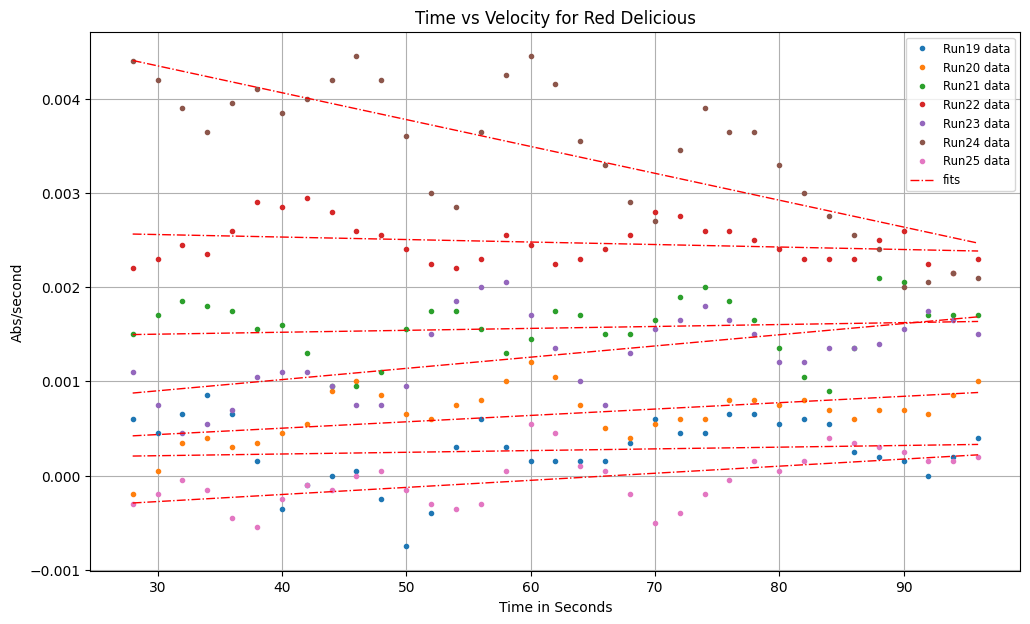

In [24]:
# Plot velocity data with fits using loops
plt.figure(figsize=(12, 7))

# Plot data points and fitted lines for each run
for run_num in runs_IIB_1:
    plt.plot(runs_time[run_num], runs_velocity[run_num], '.', label=f'Run{run_num} data')

# Plot fitted lines
for run_num in runs_IIB_1:
    if run_num == runs_IIB_1[-1]:
        plt.plot(runs_time[run_num], runs_yfit[run_num], 'r-.', linewidth=1, label='fits')
    else:
        plt.plot(runs_time[run_num], runs_yfit[run_num], 'r-.', linewidth=1)

plt.title('Time vs Velocity for Red Delicious')
plt.xlabel('Time in Seconds')
plt.ylabel('Abs/second')
plt.legend(loc='best', fontsize='small')
plt.grid(True)
plt.show()

## Inhibitor Concentration 2

In [25]:
# Fit Time vs Velocity data for Inhibitor Concentration 2
# Loop through runs and perform linear regression
for run_num in runs_IIB_2:
    # Perform linear regression using the run's own time2 array
    runs_fit[run_num] = stats.linregress(runs_time[run_num], runs_velocity[run_num])
    
    # Calculate the fitted y values
    runs_yfit[run_num] = runs_fit[run_num].slope * runs_time[run_num] + runs_fit[run_num].intercept

# Display fit statistics
print("=" * 60)
print("INHIBITOR CONCENTRATION 2 - FIT STATISTICS")
print("=" * 60)

for run_num in runs_IIB_2:
    fit = runs_fit[run_num]
    print(f"\nRun{run_num} fit statistics:")
    print(f"  Slope: {fit.slope:.6e} ± {fit.stderr:.6e}")
    print(f"  Intercept: {fit.intercept:.6e} ± {fit.intercept_stderr:.6e}")
    print(f"  R-squared: {fit.rvalue**2:.6f}")

# Extract initial velocities
for run_num in runs_IIB_2:
    V0[run_num] = runs_fit[run_num].intercept
    V0_err[run_num] = runs_fit[run_num].intercept_stderr

# Display results
print("\n" + "=" * 60)
print("Initial Velocities (V0) for Inhibitor Concentration 2:")
print("=" * 60)
for run_num in runs_IIB_2:
    print(f'V0 Run{run_num}: {V0[run_num]:.2e} ± {V0_err[run_num]:.2e}')

INHIBITOR CONCENTRATION 2 - FIT STATISTICS

Run27 fit statistics:
  Slope: 4.229704e-06 ± 3.133951e-06
  Intercept: -1.779560e-04 ± 2.043567e-04
  R-squared: 0.052310

Run28 fit statistics:
  Slope: 1.563022e-05 ± 4.767544e-06
  Intercept: -4.019299e-04 ± 3.108790e-04
  R-squared: 0.245685

Run29 fit statistics:
  Slope: 1.370445e-05 ± 3.006571e-06
  Intercept: 3.874685e-04 ± 1.960506e-04
  R-squared: 0.386353

Run30 fit statistics:
  Slope: -3.550409e-06 ± 3.130734e-06
  Intercept: 2.164411e-03 ± 2.041469e-04
  R-squared: 0.037510

Run31 fit statistics:
  Slope: -1.416673e-05 ± 2.185339e-06
  Intercept: 3.399764e-03 ± 1.425002e-04
  R-squared: 0.560143

Run32 fit statistics:
  Slope: -1.332631e-05 ± 1.772010e-06
  Intercept: 3.469088e-03 ± 1.155481e-04
  R-squared: 0.631520

Initial Velocities (V0) for Inhibitor Concentration 2:
V0 Run27: -1.78e-04 ± 2.04e-04
V0 Run28: -4.02e-04 ± 3.11e-04
V0 Run29: 3.87e-04 ± 1.96e-04
V0 Run30: 2.16e-03 ± 2.04e-04
V0 Run31: 3.40e-03 ± 1.43e-04
V0 Run

## Plot velocity with fits for Inhibitor Concentration 2

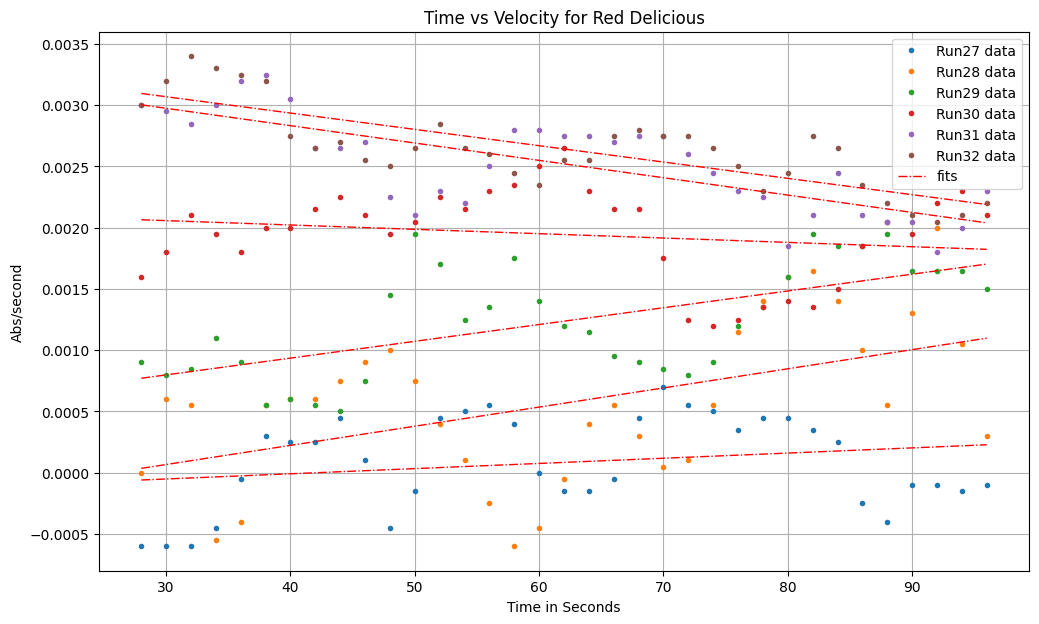

In [26]:
# Plot velocity with fits for Inhibitor Concentration 2
plt.figure(figsize=(12, 7))

# Plot data points
for run_num in runs_IIB_2:
    plt.plot(runs_time[run_num], runs_velocity[run_num], '.', label=f'Run{run_num} data')

# Plot fitted lines
for run_num in runs_IIB_2:
    if run_num == runs_IIB_2[-1]:
        plt.plot(runs_time[run_num], runs_yfit[run_num], 'r-.', linewidth=1, label='fits')
    else:
        plt.plot(runs_time[run_num], runs_yfit[run_num], 'r-.', linewidth=1)

plt.title('Time vs Velocity for Red Delicious')
plt.xlabel('Time in Seconds')
plt.ylabel('Abs/second')
plt.legend(loc='best')
plt.grid(True)
plt.show()

## Inhibitor Concentration 3

In [27]:
# Fit Time vs Velocity data for Inhibitor Concentration 3
# Loop through runs and perform linear regression
for run_num in runs_IIB_3:
    # Perform linear regression using the run's own time array
    runs_fit[run_num] = stats.linregress(runs_time[run_num], runs_velocity[run_num])
    
    # Calculate the fitted y values
    runs_yfit[run_num] = runs_fit[run_num].slope * runs_time[run_num] + runs_fit[run_num].intercept

# Display fit statistics
print("=" * 60)
print("INHIBITOR CONCENTRATION 3 - FIT STATISTICS")
print("=" * 60)

for run_num in runs_IIB_3:
    fit = runs_fit[run_num]
    print(f"\nRun{run_num} fit statistics:")
    print(f"  Slope: {fit.slope:.6e} ± {fit.stderr:.6e}")
    print(f"  Intercept: {fit.intercept:.6e} ± {fit.intercept_stderr:.6e}")
    print(f"  R-squared: {fit.rvalue**2:.6f}")

# Extract initial velocities
for run_num in runs_IIB_3:
    V0[run_num] = runs_fit[run_num].intercept
    V0_err[run_num] = runs_fit[run_num].intercept_stderr

# Display results
print("\n" + "=" * 60)
print("Initial Velocities (V0) for Inhibitor Concentration 3:")
print("=" * 60)
for run_num in runs_IIB_3:
    print(f'V0 Run{run_num}: {V0[run_num]:.2e} ± {V0_err[run_num]:.2e}')

INHIBITOR CONCENTRATION 3 - FIT STATISTICS

Run33 fit statistics:
  Slope: 3.655396e-06 ± 2.146703e-06
  Intercept: -1.180621e-04 ± 1.399808e-04
  R-squared: 0.080767

Run34 fit statistics:
  Slope: 2.499924e-06 ± 1.877145e-06
  Intercept: 3.121476e-04 ± 1.224037e-04
  R-squared: 0.051004

Run35 fit statistics:
  Slope: 1.218422e-06 ± 2.131282e-06
  Intercept: 8.616003e-04 ± 1.389753e-04
  R-squared: 0.009807

Run36 fit statistics:
  Slope: -5.686236e-06 ± 2.931611e-06
  Intercept: 2.325403e-03 ± 1.911626e-04
  R-squared: 0.102338

Run37 fit statistics:
  Slope: -1.880949e-05 ± 3.327977e-06
  Intercept: 3.487618e-03 ± 2.170086e-04
  R-squared: 0.491872

Run38 fit statistics:
  Slope: 5.686252e-06 ± 1.031382e-05
  Intercept: 1.850309e-03 ± 6.725370e-04
  R-squared: 0.009127

Initial Velocities (V0) for Inhibitor Concentration 3:
V0 Run33: -1.18e-04 ± 1.40e-04
V0 Run34: 3.12e-04 ± 1.22e-04
V0 Run35: 8.62e-04 ± 1.39e-04
V0 Run36: 2.33e-03 ± 1.91e-04
V0 Run37: 3.49e-03 ± 2.17e-04
V0 Run38:

## Plot velocity with fits for Inhibitor Concentration 3

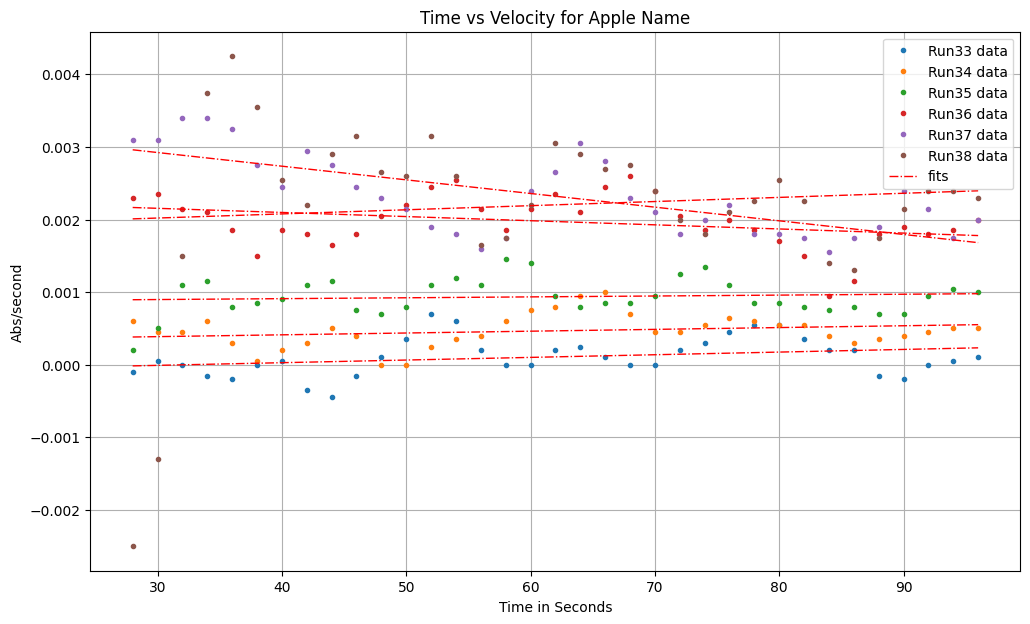

In [28]:
# Plot velocity with fits for Inhibitor Concentration 3
plt.figure(figsize=(12, 7))

# Plot data points  
for run_num in runs_IIB_3:
    plt.plot(runs_time[run_num], runs_velocity[run_num], '.', label=f'Run{run_num} data')

# Plot fitted lines
for run_num in runs_IIB_3:
    if run_num == runs_IIB_3[-1]:
        plt.plot(runs_time[run_num], runs_yfit[run_num], 'r-.', linewidth=1, label='fits')
    else:
        plt.plot(runs_time[run_num], runs_yfit[run_num], 'r-.', linewidth=1)

plt.title('Time vs Velocity for Apple Name')
plt.xlabel('Time in Seconds')
plt.ylabel('Abs/second')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Michaelis-Menten Analysis

The Michaelis-Menten equation is typically represented as:

$$v = \frac{V_{\max} \cdot [S]}{K_m + [S]}$$

where $v$ is the reaction rate, $V_{\max}$ is the maximum reaction rate, $[S]$ is the substrate concentration, and $K_m$ is the Michaelis constant.

First, we need to calculate the initial substrate concentrations in each of the runs.

## Set substrate concentrations and volumes

Enter your experimental values below:

In [29]:
# Enter concentrations
MW = 110.1  # MW of catechol
stock_S_mgL = 588  # mg/L Catechol substrate (actual used) - UPDATE THIS VALUE
stock_S = stock_S_mgL / MW / 1000  # in M

# Enter total reaction volume (V) in mL
TotV = 2.5  # total volume in cuvette (mL)

# Create a dictionary to store substrate volumes for each run
# UPDATE THESE VALUES with your actual volumes
Vol = {}

# Substrate volumes for Inhibitor Conc. 1
Vol[19] = 2.0     # volume of substrate added in run 19
Vol[20] = 1.8     # volume of substrate added in run 20
Vol[21] = 1.6
Vol[22] = 1.4
Vol[23] = 1.2
Vol[24] = 1.0
Vol[25] = 0.8
Vol[26] = 0.6

# Substrate volumes for Inhibitor Conc. 2 (same volumes, different inhibitor concentration)
# Copy volumes from Concentration 1
for i, run_num_1 in enumerate(runs_IIB_1[:6]):  # First 6 runs from IIB_1
    run_num_2 = runs_IIB_2[i]  # Corresponding run in IIB_2
    Vol[run_num_2] = Vol[run_num_1]

# Substrate volumes for Inhibitor Conc. 3 (same volumes, different inhibitor concentration)
# Copy volumes from Concentration 1
for i, run_num_1 in enumerate(runs_IIB_1[:6]):  # First 6 runs from IIB_1
    run_num_3 = runs_IIB_3[i]  # Corresponding run in IIB_3
    Vol[run_num_3] = Vol[run_num_1]

print("Substrate volumes (mL) for each run:")
for run_num in runs_IIB_1 + runs_IIB_2 + runs_IIB_3:
    print(f"  Run{run_num}: {Vol[run_num]} mL")

Substrate volumes (mL) for each run:
  Run19: 2.0 mL
  Run20: 1.8 mL
  Run21: 1.6 mL
  Run22: 1.4 mL
  Run23: 1.2 mL
  Run24: 1.0 mL
  Run25: 0.8 mL
  Run27: 2.0 mL
  Run28: 1.8 mL
  Run29: 1.6 mL
  Run30: 1.4 mL
  Run31: 1.2 mL
  Run32: 1.0 mL
  Run33: 2.0 mL
  Run34: 1.8 mL
  Run35: 1.6 mL
  Run36: 1.4 mL
  Run37: 1.2 mL
  Run38: 1.0 mL


## Calculate substrate concentrations and create data vectors

In [30]:
# Calculate substrate concentrations using a loop
# Create a dictionary to store substrate concentrations
S0 = {}

# Calculate concentration for each run
all_IIB_runs = runs_IIB_1 + runs_IIB_2 + runs_IIB_3
for run_num in all_IIB_runs:
    S0[run_num] = Vol[run_num] * stock_S / TotV

# Create arrays for each inhibitor concentration for curve fitting
# For Inhibitor conc 1
S0_I1 = np.array([S0[run_num] for run_num in runs_IIB_1])
V0_I1 = np.array([V0[run_num] for run_num in runs_IIB_1])

# For Inhibitor conc 2
S0_I2 = np.array([S0[run_num] for run_num in runs_IIB_2])
V0_I2 = np.array([V0[run_num] for run_num in runs_IIB_2])

# For Inhibitor conc 3
S0_I3 = np.array([S0[run_num] for run_num in runs_IIB_3])
V0_I3 = np.array([V0[run_num] for run_num in runs_IIB_3])

print("Substrate Concentrations (M):")
print("S0_I1:", S0_I1)
print("V0_I1:", V0_I1)
print("\nS0_I2:", S0_I2)
print("V0_I2:", V0_I2)
print("\nS0_I3:", S0_I3)
print("V0_I3:", V0_I3)

Substrate Concentrations (M):
S0_I1: [0.00427248 0.00384523 0.00341798 0.00299074 0.00256349 0.00213624
 0.00170899]
V0_I1: [ 0.00015612  0.00023201  0.00143893  0.00263697  0.00054233  0.00520324
 -0.00050158]

S0_I2: [0.00427248 0.00384523 0.00341798 0.00299074 0.00256349 0.00213624]
V0_I2: [-0.00017796 -0.00040193  0.00038747  0.00216441  0.00339976  0.00346909]

S0_I3: [0.00427248 0.00384523 0.00341798 0.00299074 0.00256349 0.00213624]
V0_I3: [-0.00011806  0.00031215  0.0008616   0.0023254   0.00348762  0.00185031]


## Visualize the data in a plot

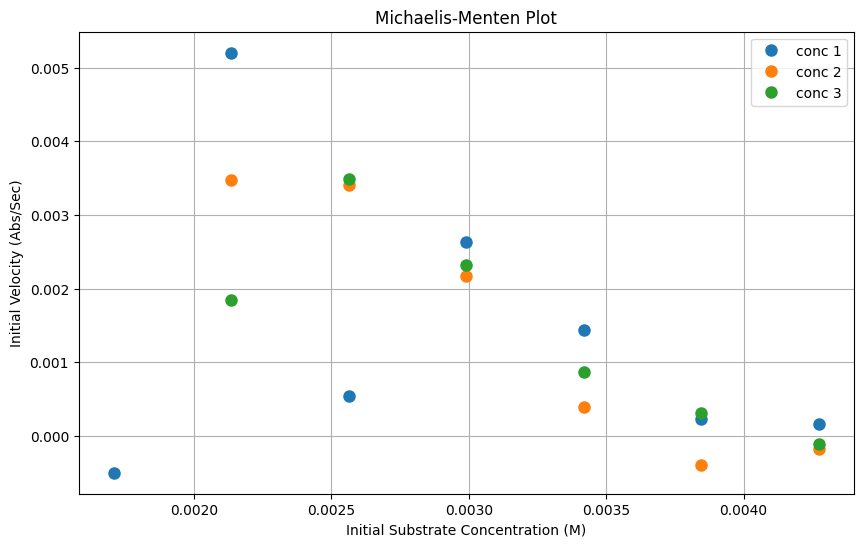

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(S0_I1, V0_I1, 'o', markersize=8, label='conc 1')
plt.plot(S0_I2, V0_I2, 'o', markersize=8, label='conc 2')
plt.plot(S0_I3, V0_I3, 'o', markersize=8, label='conc 3')
plt.title('Michaelis-Menten Plot')
plt.xlabel('Initial Substrate Concentration (M)')
plt.ylabel('Initial Velocity (Abs/Sec)')
plt.legend(loc='best')
plt.grid(True)
plt.show()

## Michaelis-Menten Least Squares Fitting

Fit the data using non-linear least squares for each inhibitor concentration.

In [32]:
# Define the Michaelis-Menten function
def michaelis_menten(S, Vmax, Km):
    """Michaelis-Menten equation: v = Vmax*S/(Km+S)"""
    return Vmax * S / (Km + S)

# Initial guess for parameters [Vmax, Km]
p0 = [0.005, 0.006]

# Fit the data for each inhibitor concentration
popt_MM_I1, pcov_MM_I1 = curve_fit(michaelis_menten, S0_I1, V0_I1, p0=p0, maxfev=10000)
Vmax_I1, Km_I1 = popt_MM_I1

popt_MM_I2, pcov_MM_I2 = curve_fit(michaelis_menten, S0_I2, V0_I2, p0=p0, maxfev=10000)
Vmax_I2, Km_I2 = popt_MM_I2

popt_MM_I3, pcov_MM_I3 = curve_fit(michaelis_menten, S0_I3, V0_I3, p0=p0, maxfev=10000)
Vmax_I3, Km_I3 = popt_MM_I3

# Display results
print(f'Inhibitor Concentration 1:')
print(f'  Fitted Vmax: {Vmax_I1:.6f}')
print(f'  Fitted Km: {Km_I1:.6f}')
print(f'\nInhibitor Concentration 2:')
print(f'  Fitted Vmax: {Vmax_I2:.6f}')
print(f'  Fitted Km: {Km_I2:.6f}')
print(f'\nInhibitor Concentration 3:')
print(f'  Fitted Vmax: {Vmax_I3:.6f}')
print(f'  Fitted Km: {Km_I3:.6f}')

Inhibitor Concentration 1:
  Fitted Vmax: 0.001150
  Fitted Km: -0.000465

Inhibitor Concentration 2:
  Fitted Vmax: 0.000499
  Fitted Km: -0.001851

Inhibitor Concentration 3:
  Fitted Vmax: 0.000683
  Fitted Km: -0.001551


## Visualize the Michaelis-Menten fits

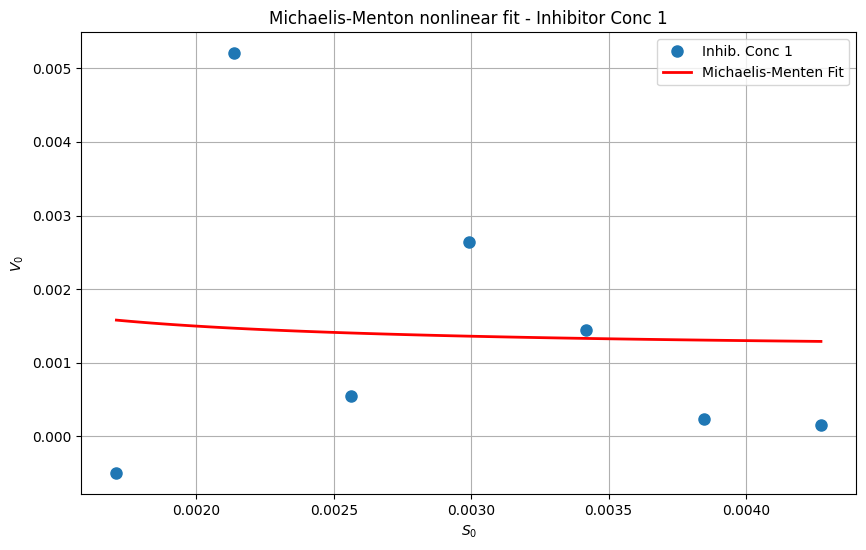

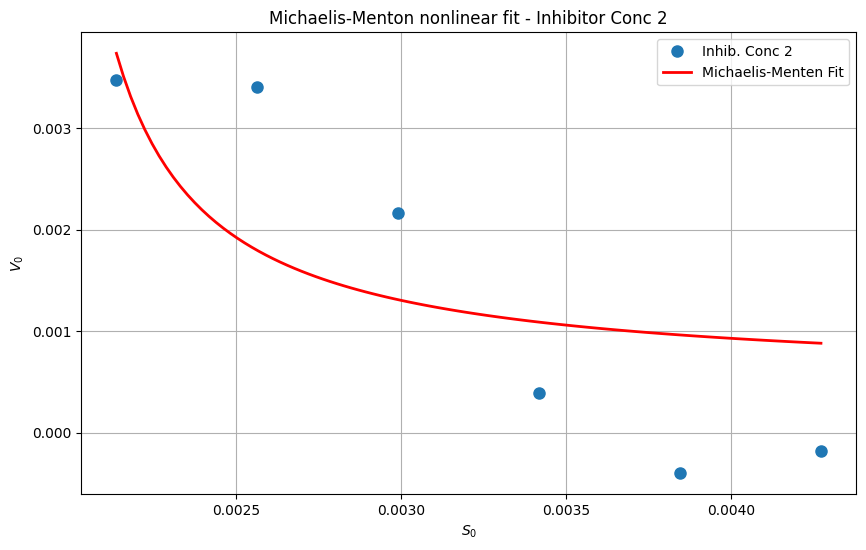

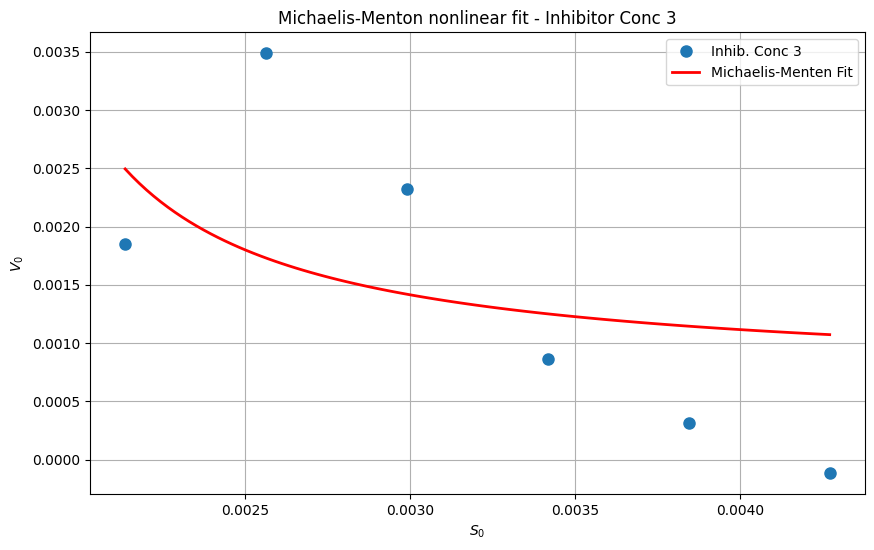

In [33]:
# Generate fitted curves
S_fit_I1 = np.linspace(S0_I1.min(), S0_I1.max(), 100)
V_fit_I1 = michaelis_menten(S_fit_I1, Vmax_I1, Km_I1)

S_fit_I2 = np.linspace(S0_I2.min(), S0_I2.max(), 100)
V_fit_I2 = michaelis_menten(S_fit_I2, Vmax_I2, Km_I2)

S_fit_I3 = np.linspace(S0_I3.min(), S0_I3.max(), 100)
V_fit_I3 = michaelis_menten(S_fit_I3, Vmax_I3, Km_I3)

# Plot Inhibitor Conc 1
plt.figure(figsize=(10, 6))
plt.plot(S0_I1, V0_I1, 'o', markersize=8, label='Inhib. Conc 1')
plt.plot(S_fit_I1, V_fit_I1, 'r-', linewidth=2, label='Michaelis-Menten Fit')
plt.xlabel('$S_0$')
plt.ylabel('$V_0$')
plt.title('Michaelis-Menton nonlinear fit - Inhibitor Conc 1')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Plot Inhibitor Conc 2
plt.figure(figsize=(10, 6))
plt.plot(S0_I2, V0_I2, 'o', markersize=8, label='Inhib. Conc 2')
plt.plot(S_fit_I2, V_fit_I2, 'r-', linewidth=2, label='Michaelis-Menten Fit')
plt.xlabel('$S_0$')
plt.ylabel('$V_0$')
plt.title('Michaelis-Menton nonlinear fit - Inhibitor Conc 2')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Plot Inhibitor Conc 3
plt.figure(figsize=(10, 6))
plt.plot(S0_I3, V0_I3, 'o', markersize=8, label='Inhib. Conc 3')
plt.plot(S_fit_I3, V_fit_I3, 'r-', linewidth=2, label='Michaelis-Menten Fit')
plt.xlabel('$S_0$')
plt.ylabel('$V_0$')
plt.title('Michaelis-Menton nonlinear fit - Inhibitor Conc 3')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Lineweaver-Burke Analysis

The Lineweaver-Burke plot is a linearization of the Michaelis-Menten equation. Though its use to derive constants is not advised (it applies the wrong statistical model), it is useful for visualizing the effect of substrate or inhibitor concentration on kinetic rate data.

## Prepare the data

Adjust the code accordingly if you need to remove data points!

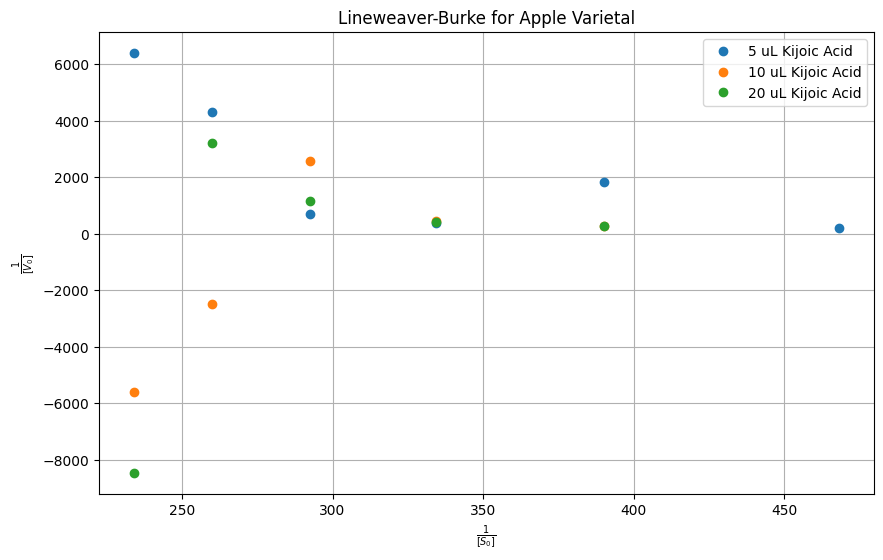

In [34]:
# Calculate inverse values
inverse_S0_I1 = 1.0 / S0_I1
inverse_V0_I1 = 1.0 / V0_I1
# Delete 1/0 = infinity (if needed)
inverse_S0_I1 = np.delete(inverse_S0_I1, 6)  # Remove last element (Run25)
inverse_V0_I1 = np.delete(inverse_V0_I1, 6)

inverse_S0_I2 = 1.0 / S0_I2
inverse_V0_I2 = 1.0 / V0_I2
# Delete 1/0 = infinity (if needed)
inverse_S0_I2 = np.delete(inverse_S0_I2, 5)  # Remove last element
inverse_V0_I2 = np.delete(inverse_V0_I2, 5)

inverse_S0_I3 = 1.0 / S0_I3
inverse_V0_I3 = 1.0 / V0_I3
# Delete 1/0 = infinity (if needed)
inverse_S0_I3 = np.delete(inverse_S0_I3, 5)  # Remove last element
inverse_V0_I3 = np.delete(inverse_V0_I3, 5)

# Plot to check linearity
plt.figure(figsize=(10, 6))
plt.plot(inverse_S0_I1, inverse_V0_I1, 'o', label='5 uL Kijoic Acid')
plt.plot(inverse_S0_I2, inverse_V0_I2, 'o', label='10 uL Kijoic Acid')
plt.plot(inverse_S0_I3, inverse_V0_I3, 'o', label='20 uL Kijoic Acid')
plt.title('Lineweaver-Burke for Apple Varietal')
plt.xlabel('$\\frac{1}{[S_0]}$')
plt.ylabel('$\\frac{1}{[V_0]}$')
plt.legend(loc='best')
plt.grid(True)
plt.show()

## Fit the linearized data

In [35]:
# Perform linear regression
LB_fit_I1 = stats.linregress(inverse_S0_I1, inverse_V0_I1)
LB_I1_yfit = LB_fit_I1.slope * inverse_S0_I1 + LB_fit_I1.intercept

LB_fit_I2 = stats.linregress(inverse_S0_I2, inverse_V0_I2)
LB_I2_yfit = LB_fit_I2.slope * inverse_S0_I2 + LB_fit_I2.intercept

LB_fit_I3 = stats.linregress(inverse_S0_I3, inverse_V0_I3)
LB_I3_yfit = LB_fit_I3.slope * inverse_S0_I3 + LB_fit_I3.intercept

# Display coefficients
print("Inhibitor Concentration 1:")
print(f"  Intercept: {LB_fit_I1.intercept:.6e} ± {LB_fit_I1.intercept_stderr:.6e}")
print(f"  Slope: {LB_fit_I1.slope:.6e} ± {LB_fit_I1.stderr:.6e}")
print(f"  R-squared: {LB_fit_I1.rvalue**2:.6f}")

print("\nInhibitor Concentration 2:")
print(f"  Intercept: {LB_fit_I2.intercept:.6e} ± {LB_fit_I2.intercept_stderr:.6e}")
print(f"  Slope: {LB_fit_I2.slope:.6e} ± {LB_fit_I2.stderr:.6e}")
print(f"  R-squared: {LB_fit_I2.rvalue**2:.6f}")

print("\nInhibitor Concentration 3:")
print(f"  Intercept: {LB_fit_I3.intercept:.6e} ± {LB_fit_I3.intercept_stderr:.6e}")
print(f"  Slope: {LB_fit_I3.slope:.6e} ± {LB_fit_I3.stderr:.6e}")
print(f"  R-squared: {LB_fit_I3.rvalue**2:.6f}")

Inhibitor Concentration 1:
  Intercept: 9.223538e+03 ± 3.363030e+03
  Slope: -2.097521e+01 ± 9.909036e+00
  R-squared: 0.528343

Inhibitor Concentration 2:
  Intercept: -1.092361e+04 ± 6.967157e+03
  Slope: 3.298664e+01 ± 2.267651e+01
  R-squared: 0.413609

Inhibitor Concentration 3:
  Intercept: -9.982131e+03 ± 1.173603e+04
  Slope: 3.078556e+01 ± 3.819811e+01
  R-squared: 0.177980


## Plot Lineweaver-Burke with all inhibitor concentrations

Edit the legend and axis labels to match your data!

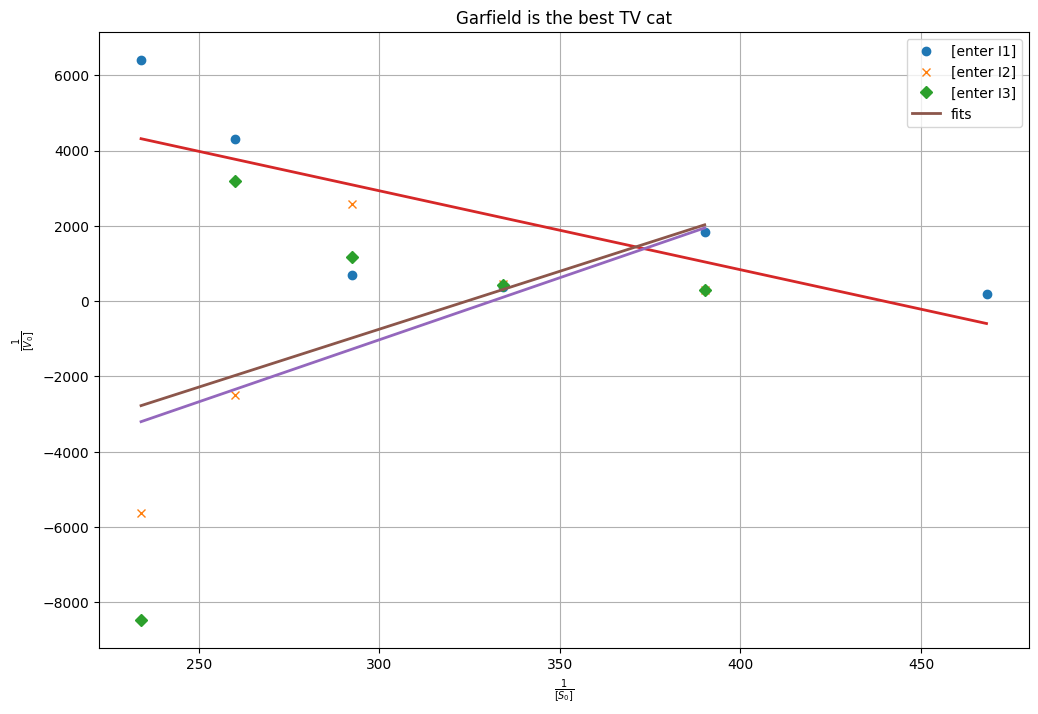

In [36]:
plt.figure(figsize=(12, 8))
# Plot data points
plt.plot(inverse_S0_I1, inverse_V0_I1, 'o', label='[enter I1]')
plt.plot(inverse_S0_I2, inverse_V0_I2, 'x', label='[enter I2]')
plt.plot(inverse_S0_I3, inverse_V0_I3, 'D', label='[enter I3]')
# Plot fits
plt.plot(inverse_S0_I1, LB_I1_yfit, '-', linewidth=2)
plt.plot(inverse_S0_I2, LB_I2_yfit, '-', linewidth=2)
plt.plot(inverse_S0_I3, LB_I3_yfit, '-', linewidth=2, label='fits')
plt.xlabel('$\\frac{1}{[S_0]}$')
plt.ylabel('$\\frac{1}{[V_0]}$')
plt.title('Garfield is the best TV cat')
plt.legend(loc='best')
plt.grid(True)
plt.show()


# Summary

Create a summary figure with Michaelis-Menten and Lineweaver-Burke plots

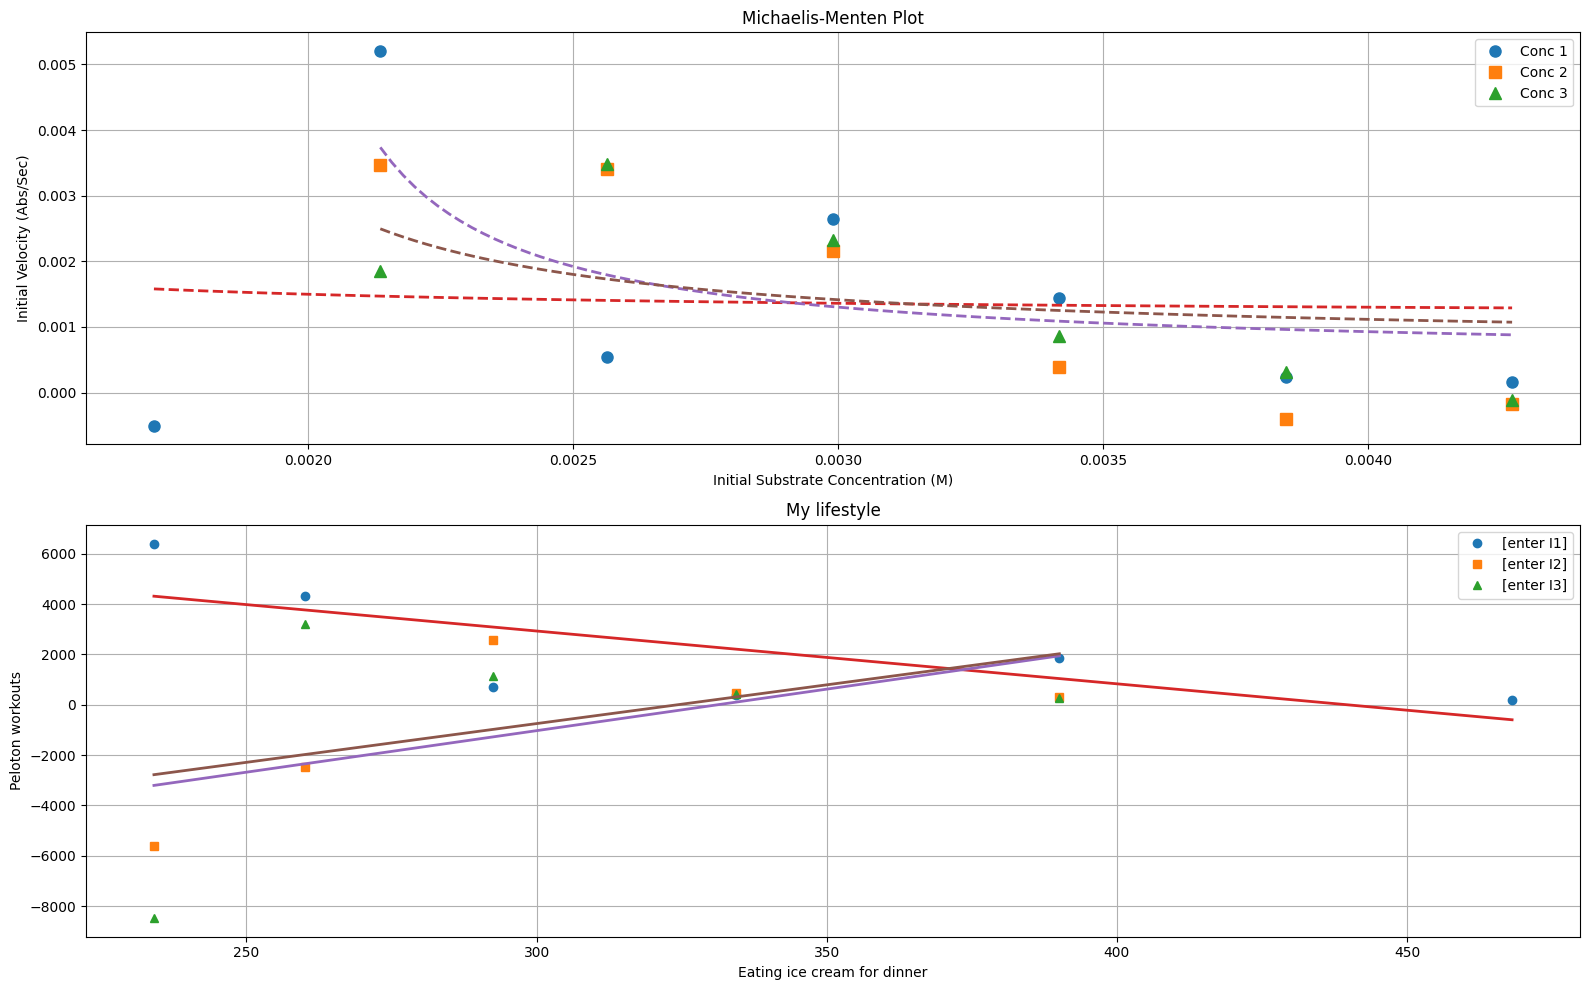

In [37]:
fig = plt.figure(figsize=(16, 10))

# Plot Michaelis-Menten
ax1 = plt.subplot(2, 1, 1)
ax1.plot(S0_I1, V0_I1, 'o', markersize=8, label='Conc 1')
ax1.plot(S0_I2, V0_I2, 's', markersize=8, label='Conc 2')
ax1.plot(S0_I3, V0_I3, '^', markersize=8, label='Conc 3')
ax1.plot(S_fit_I1, V_fit_I1, '--', linewidth=2)
ax1.plot(S_fit_I2, V_fit_I2, '--', linewidth=2)
ax1.plot(S_fit_I3, V_fit_I3, '--', linewidth=2)
ax1.set_title('Michaelis-Menten Plot')
ax1.set_xlabel('Initial Substrate Concentration (M)')
ax1.set_ylabel('Initial Velocity (Abs/Sec)')
ax1.legend(loc='best')
ax1.grid(True)

# Plot Lineweaver-Burke
ax2 = plt.subplot(2, 1, 2)
ax2.plot(inverse_S0_I1, inverse_V0_I1, 'o', label='[enter I1]')
ax2.plot(inverse_S0_I2, inverse_V0_I2, 's', label='[enter I2]')
ax2.plot(inverse_S0_I3, inverse_V0_I3, '^', label='[enter I3]')
ax2.plot(inverse_S0_I1, LB_I1_yfit, '-', linewidth=2)
ax2.plot(inverse_S0_I2, LB_I2_yfit, '-', linewidth=2)
ax2.plot(inverse_S0_I3, LB_I3_yfit, '-', linewidth=2)
ax2.set_xlabel('Eating ice cream for dinner')
ax2.set_ylabel('Peloton workouts')
ax2.set_title('My lifestyle')
ax2.legend(loc='best')
ax2.grid(True)

plt.tight_layout()
plt.show()